In [5]:
import pandas as pd
import xml.etree.ElementTree as ET
from pathlib import Path
import sys

ROOT = Path.cwd().parent.parent
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from scripts.src.helpers import parse_edges
import scripts.src.inputs.config as cfg
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
root = ET.parse(Path("/home/fullsuper/irene/dtSumo/scripts/output/simulation-out/out_MA_no_TLS/VehTraces_marouter_AM.xml")).getroot()
corridor_edges = {"1113770110#1", "1113770110#2", "121952561#0", "121952561#1",
                   "121952561#2", "121952561#3", "154986388#0", "154986388#1",
                   "154986388#2", "154986388#3"}
n = sum(1 for veh in root.findall(".//vehicle")
        if veh.find("route") is not None
        and corridor_edges & set(veh.find("route").get("edges", "").split()))
print(f"Veicoli sul corridoio arterioso storico, config finale: {n}")

tree_new = ET.parse("/home/fullsuper/irene/dtSumo/scripts/output/simulation-out/out_MA_no_TLS/VehTraces_marouter_AM_TEST.xml")
root_new = tree_new.getroot()

n_round0_no_adaption = sum(1 for veh in root_new.findall(".//vehicle")
    if veh.find("route") is not None
    and corridor_edges & set(veh.find("route").get("edges", "").split()))
print(f"Corridoio, priority nuova SENZA weight-adaption: {n_round0_no_adaption}")

Veicoli sul corridoio arterioso storico, config finale: 1393
Corridoio, priority nuova SENZA weight-adaption: 1592


In [8]:
# import xml.etree.ElementTree as ET

# tree = ET.parse("/home/fullsuper/irene/dtSumo/scripts/output/marouter-workdir/MA_no_TLS_AM/marouter_output_extended.rou.xml")
# root = tree.getroot()

# count = 0
# for veh in root.findall("vehicle") + root.findall("trip"):
#     route_el = veh.find("route")
#     count += 1
# print(f"Veicoli con destinazione MAROUTER {count}")

In [10]:
vehroutes_am  = Path("/home/fullsuper/irene/dtSumo/scripts/output/simulation-out/out_MA_no_TLS/VehTraces_marouter_AM.xml")

tree = ET.parse(vehroutes_am)
root = tree.getroot()

data_list = []

for veh in root.findall("vehicle"):
    veh_data = {
        "id": veh.get("id"), 
        "depart": float(veh.get("depart")) if veh.get("depart") else None,
        "departLane": veh.get("departLane"),
        "departSpeed": float(veh.get("departSpeed")) if veh.get("departSpeed") else None,
        "fromTaz": veh.get("fromTaz"),
        "toTaz": veh.get("toTaz"),
        "speedFactor": float(veh.get("speedFactor")) if veh.get("speedFactor") else None, # Corretto refuso 'fpeedFactor'
        "arrival": float(veh.get("arrival")) if veh.get("arrival") else None,
        "routeLength": float(veh.get("routeLength")) if veh.get("routeLength") else None,
    }
    
    route = veh.find("route")
    if route is not None:
        veh_data["route_edges"] = route.get("edges")
        veh_data["route_exitTimes"] = route.get("exitTimes") if route.get("exitTimes") else None
    
    param = veh.find("param")
    if param is not None:
        veh_data["param_key"] = param.get("key")
        veh_data["param_value"] = float(param.get("value"))
        
    data_list.append(veh_data)

df_res = pd.DataFrame(data_list)
df_res

,id,depart,departLane,departSpeed,fromTaz,toTaz,speedFactor,arrival,routeLength,route_edges,route_exitTimes
0,7601,28802.0,0,21.6689,10007,10012,0.9752,28879.0,582.29,1306068768#2 134572328#0 134572328#1 130547465...,28803.00 28803.00 28807.00 28808.00 28809.00 2...
1,11410,28802.0,0,4.7795,10012,10007,1.0827,29182.0,978.94,-678628384#3 -678628384#2 1307721869#7 1307721...,28803.00 28804.00 28806.00 28811.00 28816.00 2...
2,26881,28803.0,0,16.6736,635,10002,1.2004,29077.0,1372.06,-154986390 -4761525#1 116647088#0 116647088#1 ...,28812.00 28819.00 28826.00 28832.00 28842.00 2...
3,20693,28803.0,0,14.5262,573,10009,1.0458,31023.0,1005.26,124804823#0 1311144281#14 1311144281#15 131114...,28813.00 28823.00 28823.00 28824.00 28826.00 2...
4,603,28803.0,2,23.9465,10001,10018,1.0777,28819.0,210.23,1305781749 1305781751 1305781750#0 1305781750#...,28807.00 28808.00 28810.00 28810.00 28811.00 2...
...,...,...,...,...,...,...,...,...,...,...,...
27582,10991,76839.0,0,0.1951,10011,10007,0.9234,96299.0,615.67,134155167#1 1305474659#0 1305474659#1 13054746...,94152.00 95367.00 95373.00 95672.00 96281.00 9...
27583,10992,77142.0,0,0.0753,10011,10007,0.9706,96602.0,615.67,134155167#1 1305474659#0 1305474659#1 13054746...,94457.00 95672.00 95677.00 95978.00 96586.00 9...
27584,10993,77447.0,0,0.5325,10011,10007,1.0219,96908.0,615.67,134155167#1 1305474659#0 1305474659#1 13054746...,94763.00 95978.00 95984.00 96284.00 96892.00 9...
27585,10994,77753.0,0,0.2231,10011,10007,1.0120,97215.0,615.67,134155167#1 1305474659#0 1305474659#1 13054746...,95067.00 96284.00 96290.00 96589.00 97199.00 9...


In [ ]:
import xml.etree.ElementTree as ET

tree = ET.parse(vehroutes_am)
root = tree.getroot()

funnel_edges = {"81240118", "81240119"}

count_via_funnel = 0
funnel_depart_times = []
n_total = 0
n_no_route = 0

for veh in root.findall("vehicle"):
    n_total += 1
    routes = veh.findall("route")
    if not routes:
        n_no_route += 1
        continue
    last_route = routes[-1]
    edges = last_route.get("edges", "").split()
    if not edges:
        n_no_route += 1
        continue

    if funnel_edges & set(edges):
        count_via_funnel += 1
        funnel_depart_times.append(float(veh.get("depart", -1)))

print(f"Veicoli totali: {n_total}")
print(f"Senza route: {n_no_route}")
print(f"Veicoli che attraversano l'imbuto (route REALMENTE percorsa): {count_via_funnel}")

Veicoli totali: 27587
Senza route: 0
Veicoli che attraversano l'imbuto (route REALMENTE percorsa): 514


In [13]:
import pandas as pd

df = pd.DataFrame({"depart": funnel_depart_times})
df["bin_10min"] = (df["depart"] // 600) * 600

counts_per_bin = df.groupby("bin_10min").size()
print(counts_per_bin)

# capacità nominale per bin di 10 minuti (proporzionale a 800 vic/2h)
cap_per_10min = 800 / 12  # ≈ 66.7 veicoli ogni 10 minuti
print(f"\nCapacità di riferimento per bin da 10 min: ~{cap_per_10min:.0f}")
print(f"Bin che la superano: {(counts_per_bin > cap_per_10min).sum()} / {len(counts_per_bin)}")

bin_10min
28800.0    69
29400.0    73
30000.0    41
30600.0    55
31200.0    44
31800.0    38
32400.0     3
33000.0     2
33600.0     7
34200.0     2
34800.0     2
35400.0     2
36000.0    11
36600.0    10
37200.0    52
37800.0    17
38400.0    18
39000.0     2
40200.0     1
41400.0     1
43800.0     1
45000.0     1
46200.0     1
47400.0     3
48000.0     2
48600.0     4
49800.0     3
50400.0     3
51000.0     7
51600.0     5
52200.0     5
52800.0     1
54000.0     1
55200.0     2
55800.0     3
56400.0     4
57000.0     9
57600.0     5
58200.0     3
58800.0     1
dtype: int64

Capacità di riferimento per bin da 10 min: ~67
Bin che la superano: 2 / 40


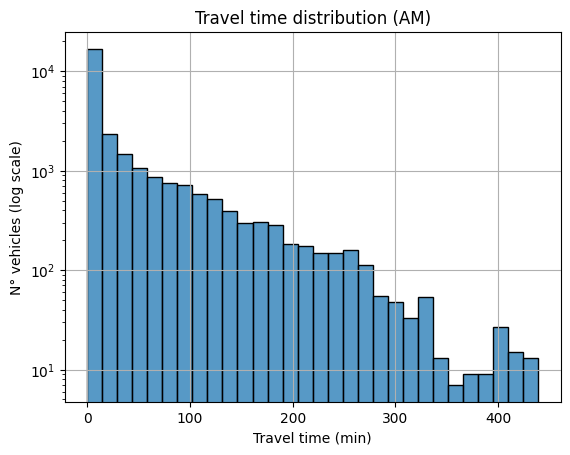

In [14]:
df_res["duration"] = (df_res['arrival'] - df_res['depart']) / 60
sns.histplot(df_res["duration"], bins=30)
plt.title('Travel time distribution (AM)')
plt.xlabel('Travel time (min)')
plt.ylabel("N° vehicles (log scale)")
plt.yscale(value="log")
plt.grid(True)

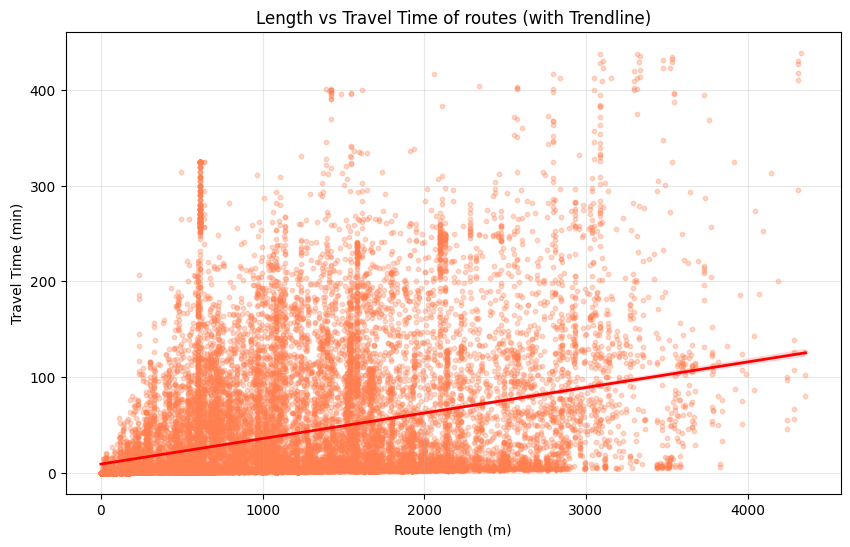

In [ ]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=df_res, 
    x='routeLength', 
    y='duration', 
    color='coral',
    scatter_kws={'alpha': 0.3, 's': 10},
    line_kws={'color': 'red', 'linewidth': 2}
)

plt.title('Length vs Travel Time of routes (with Trendline)')
plt.xlabel('Route length (m)')
plt.ylabel('Travel Time (min)')
plt.grid(True, alpha=0.3)
plt.show()

/tmp/ipykernel_2859443/3386253543.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_edges.values, y=top_edges.index, palette='viridis')


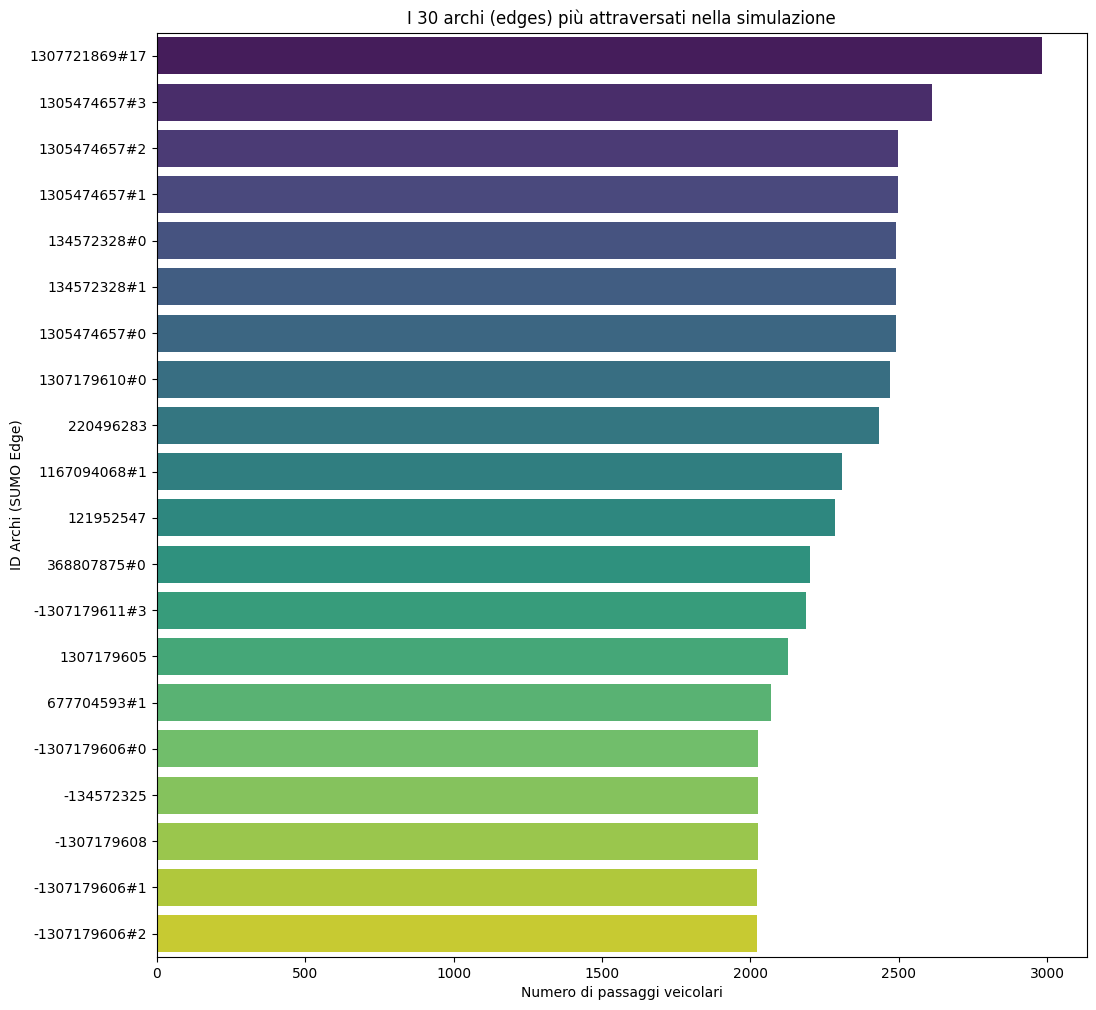

In [16]:
all_edges = df_res['route_edges'].str.split(' ').explode()
top_edges = all_edges.value_counts().head(20)

plt.figure(figsize=(12, 12))
sns.barplot(x=top_edges.values, y=top_edges.index, palette='viridis')
plt.title('I 30 archi (edges) più attraversati nella simulazione')
plt.xlabel('Numero di passaggi veicolari')
plt.ylabel('ID Archi (SUMO Edge)')
plt.show()

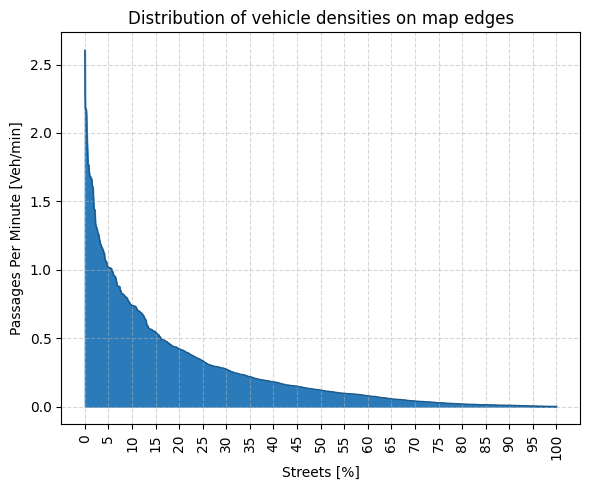

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


durata_minuti = (df_res['arrival'].max() - df_res['depart'].min()) / 60.0
edge_counts = df_res['route_edges'].str.split(' ').explode().value_counts()
passages_per_min = (edge_counts / durata_minuti).sort_values(ascending=False).values

num_streets = len(passages_per_min)
streets_percentage = np.linspace(0, 100, num_streets)

plt.figure(figsize=(6, 5))
plt.fill_between(streets_percentage, passages_per_min, color='#2b7bba')
plt.plot(streets_percentage, passages_per_min, color='#1d5a8a', linewidth=1)

plt.title("Distribution of vehicle densities on map edges")
plt.xlabel("Streets [%]")
plt.ylabel("Passages Per Minute [Veh/min]")
plt.xlim(-5, 105)
plt.xticks(ticks=np.arange(0, 101, 5), rotation=90)
plt.grid(True, alpha=0.5, linestyle='--')
plt.tight_layout()
plt.show()

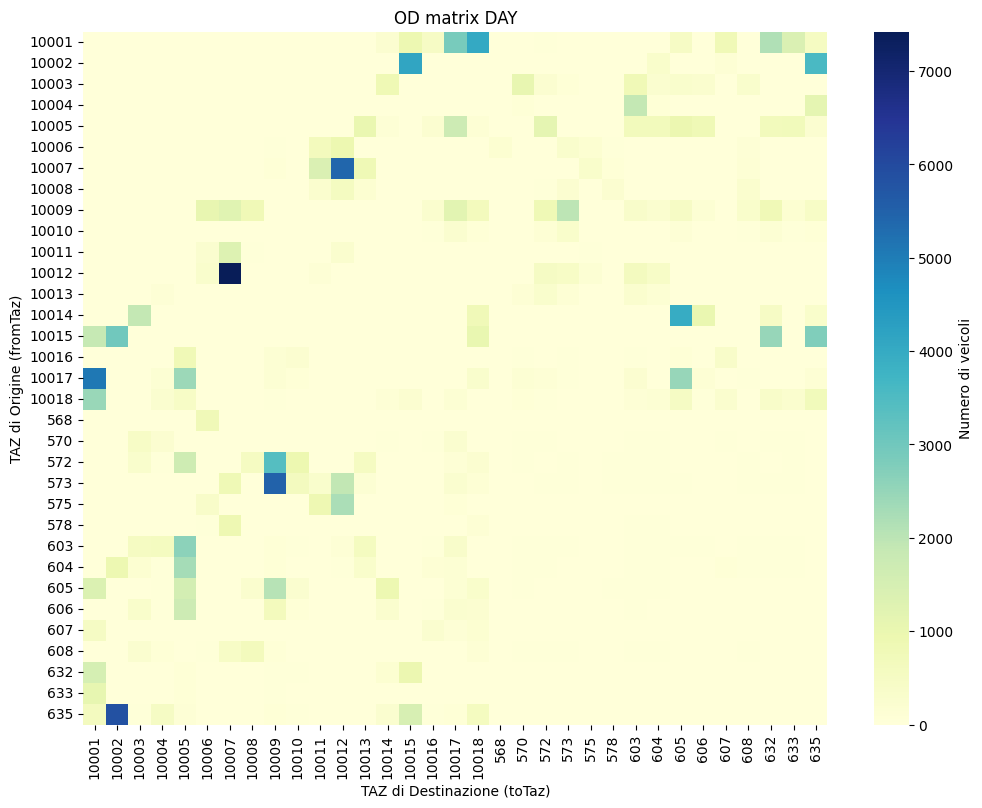

In [ ]:
od_matrix = df_res.pivot_table(index='fromTaz', columns='toTaz', aggfunc='size', fill_value=0)

plt.figure(figsize=(12, 9))
sns.heatmap(od_matrix, annot=False, fmt="d", cmap="YlGnBu", cbar_kws={'label': 'Numero di veicoli'})
plt.title('OD matrix DAY')
plt.xlabel('TAZ di Destinazione (toTaz)')
plt.ylabel('TAZ di Origine (fromTaz)')
plt.show()